**Experiment Title**: To implement ARIMA model in Python Programming

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [32]:
df = pd.read_csv('/content/1_Daily_minimum_temps.csv')

In [33]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

/tmp/ipykernel_4214/1929082916.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [34]:
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
df.dropna(inplace=True)

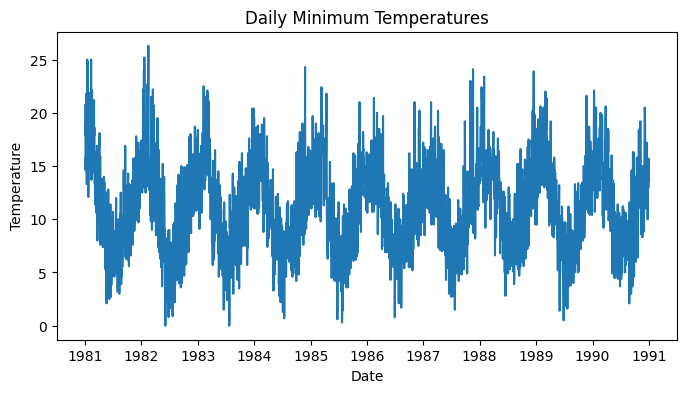

In [35]:
plt.figure(figsize=(8,4))
plt.plot(df['Temp'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Daily Minimum Temperatures')
plt.show()

In [36]:
adf_result = adfuller(df['Temp'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.444652847181708
p-value: 0.00024723724658534517


In [37]:
train_size = int(len(df) * 0.8)
train = df['Temp'][:train_size]
test = df['Temp'][train_size:]

In [38]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [39]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [40]:
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

In [41]:
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 27.771834892340664
RMSE: 5.26989894517349


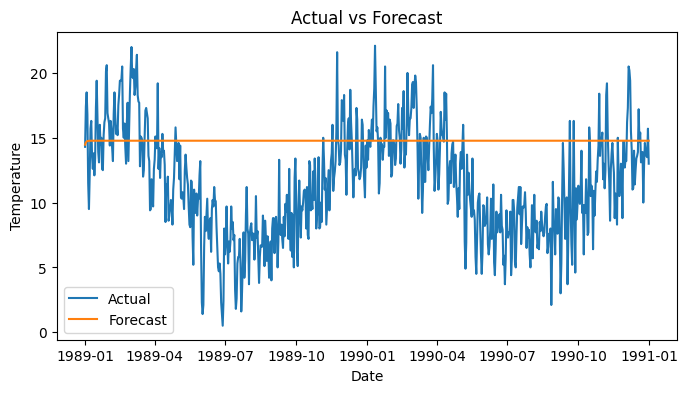

In [42]:
plt.figure(figsize=(8,4))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Actual vs Forecast')
plt.legend()
plt.show()